In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [3]:
## Ocean Mask
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

## N

In [4]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp).sel(valid_time = slice('1979', '2024'))

#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})


#over indo-pac only
n = n.where(ocean_mask)

#convert to w/m2
n = n/(60**2*24)
#total short and longwave
n['n'] = n.tsr+n.ttr

#weights
weights = np.cos(np.deg2rad(n.lat))

#calculate mean over area (weighted)
#calculate yearly april-sept mean
n = n.weighted(weights).mean(['lat', 'lon'])

In [5]:
clim = n.sel(time = slice('1991', '2020')).groupby('time.month').mean()
n = n.groupby('time.month') - clim

## Clouds

In [6]:
fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

clodus = clouds.drop_vars(['mcc', 'hcc'])

#mask
clouds = clouds.where(ocean_mask)
#cmmpute means
weights = np.cos(np.deg2rad(clouds.lat))
clouds = clouds.weighted(weights).mean(['lat', 'lon'])

In [7]:
 
clim = clouds.sel(time = slice('1991', '2020')).groupby('time.month').mean()
clouds = clouds.groupby('time.month') - clim

## LTS

In [8]:
fp = '/data/jmex/ERA5/monthly/temp_pressure/era5_t79.nc'
t1000 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 1000,
                            valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'],)
t700 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 700,
                              valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'])


#change the longitude defintion to 0-360
t700['longitude'] = (t700['longitude']+360)%360
t700 = t700.sortby('longitude')

#change the longitude defintion to 0-360
t1000['longitude'] = (t1000['longitude']+360)%360
t1000 = t1000.sortby('longitude')


#mask
t1000 = t1000.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'}).where(ocean_mask)
t700 = t700.rename({'latitude':'lat', 'longitude':'lon',  'valid_time':'time'}).where(ocean_mask)

#convert to potential
t700['t'] = convert_to_potential_temperature(t700.t, p = 700)
t1000['t'] = convert_to_potential_temperature(t1000.t, p = 1000)

#weigthed mean 
weights = np.cos(np.deg2rad(t700.lat))
t700 = t700.weighted(weights).mean(['lat', 'lon'])
t1000 = t1000.weighted(weights).mean(['lat', 'lon'])

In [9]:
LTS = t700-t1000
 
clim = LTS.sel(time = slice('1991', '2020')).groupby('time.month').mean()
LTS = LTS.groupby('time.month') - clim

# Yearly values

In [10]:
LTS_ann = LTS.where((LTS.time.dt.month <=9) & (LTS.time.dt.month >=4)).groupby('time.year').mean('time')

In [11]:
clouds_ann = clouds.where((clouds.time.dt.month <=9) & (clouds.time.dt.month >=4)).groupby('time.year').mean('time')

In [12]:
n_ann = n.where((n.time.dt.month <=9) & (n.time.dt.month >=4)).groupby('time.year').mean('time')

## Plotting

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.stats import linregress

composite_years = [1982, 1987, 1991, 1997, 2015]


def plot_normalized_scatter(x, y, x_label, y_label, detrend_data=False, legend = True):
    """
    Plots a normalized scatter plot with a regression line.
    
    Parameters:
    x (array-like): Data for the x-axis (will be normalized by its std).
    y (array-like): Data for the y-axis (will be normalized by its std).
    composite_years (list): List of years to highlight with black arrows.
    detrend_data (bool): If True, removes the linear trend from each dataset over time.
    """
    # Detrend x and y separately if requested
    if detrend_data:
        x = detrend(x)
        y = detrend(y)

    # Normalize data
    x_norm = x / np.std(x)
    y_norm = y / np.std(y)

    # Take yearly data (April-September average)
    x_AMJJAS = x_norm.where((x_norm.time.dt.month <= 9) & (x_norm.time.dt.month >= 4)).groupby('time.year').mean('time')
    y_AMJJAS = y_norm.where((y_norm.time.dt.month <= 9) & (y_norm.time.dt.month >= 4)).groupby('time.year').mean('time')

    # Perform linear regression
    slope, intercept, r_value, _, _ = linregress(x_norm, y_norm)

    # Create regression line
    x_vals = np.linspace(x_norm.min(), x_norm.max(), 100)
    y_vals = slope * x_vals + intercept

    # Plot
    plt.figure(figsize=(7, 5))
    sns.set_style("ticks")  # Cleaner axis style
    plt.scatter(x_norm, y_norm, alpha=0.4, color="grey")
    line, = plt.plot(x_vals, y_vals, color="black", linestyle="dashed", label=f"$R^2 = {r_value**2:.2f}$")

    """    
    #color AMJJAS 2023
    plt.scatter(x_norm.sel(time = slice('04-2023', '09-2023')), y_norm.sel(time = slice('04-2023', '09-2023')),
                                                                          alpha = 0.57, color = 'red')

    plt.scatter(x_norm.sel(time = slice('01-2023', '03-2023')), y_norm.sel(time = slice('01-2023', '03-2023')),
                                                                      alpha = 0.57, color = 'k')
    plt.scatter(x_norm.sel(time = slice('10-2023', '12-2023')), y_norm.sel(time = slice('10-2023', '12-2023')),
                                                                      alpha = 0.57, color = 'orange')
    """
    # Add arrows for composite years
    for y in composite_years:
        x_1, x0 = x_AMJJAS.sel(year=y - 1), x_AMJJAS.sel(year=y)
        y_1, y0 = y_AMJJAS.sel(year=y - 1), y_AMJJAS.sel(year=y)
        plt.arrow(x_1, y_1, x0 - x_1, y0 - y_1,
                  ec='black', fc='black', head_width=0.2, head_length=0.2, width=0.02,
                  overhang=1, length_includes_head=True)

    # Add arrow for 2023
    if 2023 in x_AMJJAS.year:
        x_1, x0 = x_AMJJAS.sel(year=2022), x_AMJJAS.sel(year=2023)
        y_1, y0 = y_AMJJAS.sel(year=2022), y_AMJJAS.sel(year=2023)
        plt.arrow(x_1, y_1, x0 - x_1, y0 - y_1,
                  ec='red', fc='red', head_width=0.2, head_length=0.2, width=0.02,
                  overhang=1, length_includes_head=True)

    # Create legend entries
    red_patch = mpatches.FancyArrowPatch(posA = (x0, x_1), posB = (y0, y_1), color='red', label='2023 Δ')
    black_patch = mpatches.FancyArrowPatch(posA = (x0, x_1), posB = (y0, y_1),color='black', label='Composite Δ')

    # Add light grey reference lines at zero
    plt.axhline(0, color="lightgrey", linestyle="dashed", linewidth=1)
    plt.axvline(0, color="lightgrey", linestyle="dashed", linewidth=1)

    # Labels and font sizes
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel(y_label, fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title(' ')  # Empty title

    # Remove spines but keep bottom/left for a cleaner look
    sns.despine()

    # Combine all legend entries and show legend
    if legend: plt.legend(handles=[line, red_patch, black_patch], fontsize=12)
    else: plt.legend(handles = [line], fontsize = 12)

        
    plt.savefig(f'Figures/FigS5{x_label}.png', dpi = 300, format = 'png', bbox_inches = 'tight')

    # Show plot
    plt.show()


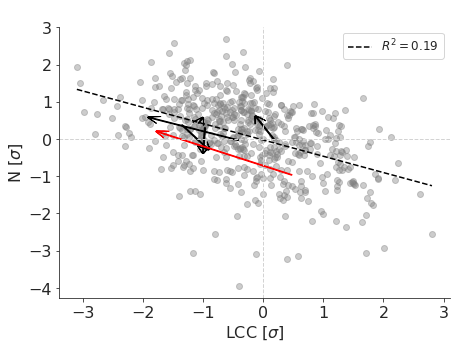

In [21]:
plot_normalized_scatter(clouds.lcc, n.n, x_label = r"LCC [$\sigma$]", y_label = r"N [$\sigma$]", legend = False)

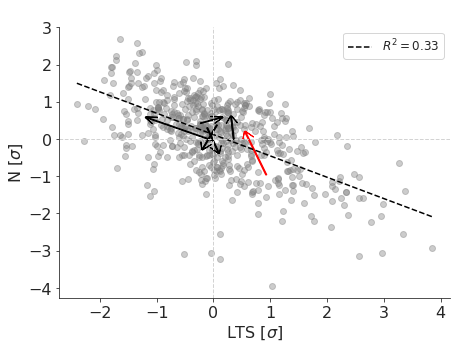

In [22]:
plot_normalized_scatter(LTS.t, n.n, x_label = r"LTS [$\sigma$]", y_label = r"N [$\sigma$]", legend = False)

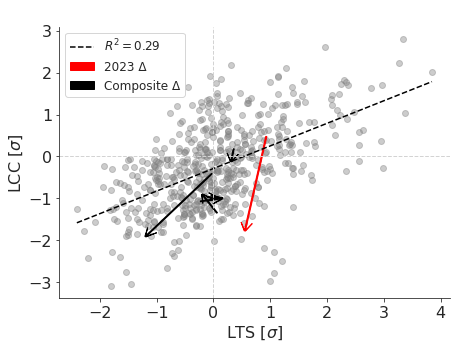

In [23]:
plot_normalized_scatter(LTS.t, clouds.lcc, x_label = r"LTS [$\sigma$]", y_label = r"LCC [$\sigma$]", legend = True)